In [1]:
!pip install -q torch_snippets fastprogress

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.9 MB/s eta 0:00:00


In [3]:
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms

# define o dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [4]:
# pipeline de transformações — converte para tensor, normaliza e move para o dispositivo
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])

# baixa o MNIST e cria os datasets de treino e validação
train_DS = MNIST('./content', train=True,  download=True, transform=img_transform)
val_DS   = MNIST('./content', train=False, download=True, transform=img_transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 49.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.24MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.51MB/s]


In [6]:
# autoencoder vanilla
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128), nn.ReLU(True), # primeira compressão
            nn.Linear(128, 64), nn.ReLU(True), # segunda compressão
            nn.Linear(64, latent_dim) # espaço latente
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(True), # primeira expansão
            nn.Linear(64, 128), nn.ReLU(True), # segunda expansão
            nn.Linear(128, 28*28), nn.Tanh() # reconstrução
        )

    def forward(self, x):
        x = x.view(len(x), -1)  # transgorma em vetor
        x = self.encoder(x) # comprime
        x = self.decoder(x) # reconstrói
        x = x.view(len(x), 1, 28, 28) # volta para formato de imagem
        return x

In [7]:
# treina um batch
def train_batch(input, model, optimizer, criterion):
    model.train()
    input = input.to(device)
    optimizer.zero_grad() # zera gradientes
    output = model(input) # gera reconstrução
    loss = criterion(output, input) # compara reconstrução com original
    loss.backward()
    optimizer.step() # atualiza os pesos
    return loss

# valida sem atualizar pesos
@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    input = input.to(device)
    output = model(input) # gera reconstrução
    return criterion(output, input) # retorna o erro

In [9]:
from fastprogress.fastprogress import master_bar, progress_bar

# cria o modelo com espaço latente
model = AutoEncoder(3).to(device)
criterion = nn.MSELoss() # erro quadrático médio
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

train_losses, val_losses = [], []
mb = master_bar(range(5)) # barra  por época

for epoch in mb:
    trn_loss_epoch = 0
    for data, _ in progress_bar(train_DS, parent=mb):  # loop de treino
        loss = train_batch(data, model, optimizer, criterion)
        trn_loss_epoch += loss.item()
    train_losses.append(trn_loss_epoch / len(train_DS))

    val_loss_epoch = 0
    for data, _ in progress_bar(val_DS, parent=mb): # loop de validação
        loss = validate_batch(data, model, criterion)
        val_loss_epoch += loss.item()
    val_losses.append(val_loss_epoch / len(val_DS))

    mb.write(f'epoca {epoch+1} | treino: {train_losses[-1]:.4f} | validação: {val_losses[-1]:.4f}')

<div><div><progress max="5" value="1"></progress> 20.00% [1/5 07:52&lt;31:30]</div><div><p>epoca 1 | treino: 0.1593 | validação: 0.1597</p></div><div><progress max="60000" value="58060"></progress> 96.77% [58060/60000 11:22&lt;00:22]</div></div>

<div><p>epoca 1 | treino: 0.1593 | validação: 0.1597</p><p>epoca 2 | treino: 0.1465 | validação: 0.1548</p><p>epoca 3 | treino: 0.1437 | validação: 0.1524</p><p>epoca 4 | treino: 0.1420 | validação: 0.1532</p><p>epoca 5 | treino: 0.1412 | validação: 0.1525</p></div>

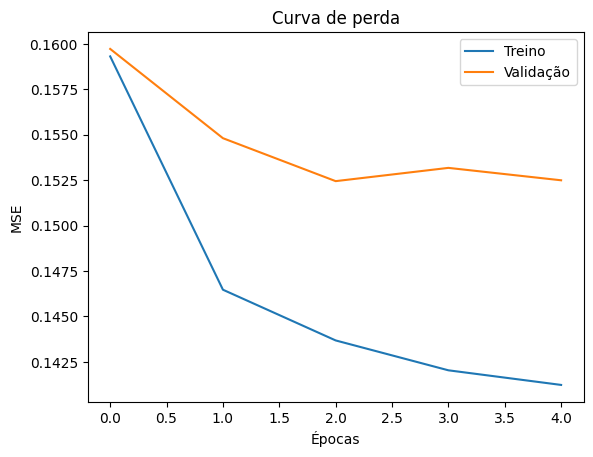

In [10]:
# plota as curvas de perda de treino e validação
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Treino')
plt.plot(val_losses,   label='Validação')
plt.title('Curva de perda'); plt.xlabel('Épocas'); plt.ylabel('MSE')
plt.legend(); plt.show()

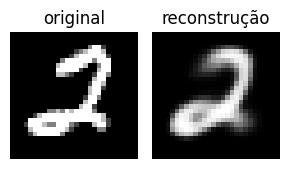

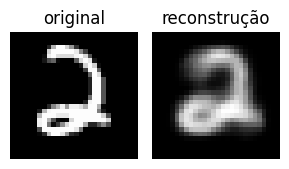

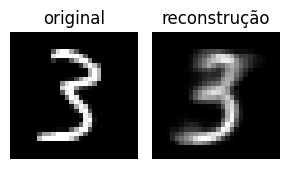

In [11]:
# compara 3 imagens
model.eval()
for _ in range(3):
    ix = np.random.randint(len(val_DS))
    im, _ = val_DS[ix]
    with torch.no_grad():
        _im = model(im[None])[0].cpu() # gera reconstrução
    fig, ax = plt.subplots(1, 2, figsize=(3, 3))
    show(im[0].cpu(), ax=ax[0], title='original') # imagem de entrada
    show(_im[0],      ax=ax[1], title='reconstrução') # imagem reconstruída
    plt.tight_layout(); plt.show()